Name : Moeez Uddin

Roll Number : 22P-9203

Section : BSCS - 6B

Task # 01 (Data Cleaning)

In [ ]:
#Importng important Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#importing data file and storing data in df
try:
    df = pd.read_csv('air_quality_data (1).csv')
    print("Data Reading Successfully")
    print(df.head())
except FileNotFoundError:
    print("File Not Found")

missing_values = df.isnull().sum() #Total Missing values in dataset
print("missing values\n",missing_values[missing_values > 0]) #printing if 1 or more missing value

outliers = (df[['PM2.5','PM10','SO2','NO2','CO','O3','WSPM','PRES','RAIN']] < 0 ).sum() #checking for outliers e.g, negative values etc.
print("\n\noutliers\n",outliers[outliers > 0])

# neg = (df['RAIN'] < 0).sum()
# print(neg)

#filling missing values
for col in ['PM2.5','PM10','SO2','NO2','CO','O3','WSPM','PRES','RAIN']:
    df[col] = df[col].fillna(df[col].mean())

df = df.ffill()

df = df[(df[['PM2.5','PM10','SO2','NO2','CO','O3','WSPM','PRES','RAIN']] >= 0).all(axis=1)] #removing negative numbers by ignoring them



Data Reading Successfully
   No  year  month  day  hour  PM2.5  PM10   SO2   NO2     CO    O3  TEMP  \
0   1  2013      3    7     0    4.0   4.0   4.0   7.0  300.0  77.0  -0.7   
1   2  2013      3    1     1    8.0   8.0   4.0   7.0  300.0  77.0  -1.1   
2   3  2013      3    1     2    7.0   7.0   5.0  10.0  300.0  73.0  -1.1   
3   4  2013      3    1     3    6.0   6.0  11.0  11.0  300.0  72.0  -1.4   
4   5  2013      3    1     4    3.0   3.0  12.0  12.0  300.0  72.0  -2.0   

     PRES  DEWP  RAIN   wd  WSPM       station  
0  1023.0 -18.8   0.0  NNW   4.4  Aotizhongxin  
1  1023.2 -18.2   0.0    N   4.7  Aotizhongxin  
2  1023.5 -18.2   0.0  NNW   5.6  Aotizhongxin  
3  1024.5 -19.4   0.0   NW   3.1  Aotizhongxin  
4  1025.2 -19.5   0.0    N   2.0  Aotizhongxin  
missing values
 PM2.5     925
PM10      718
SO2       935
NO2      1023
CO       1776
O3       1719
TEMP       20
PRES       20
DEWP       20
RAIN       20
wd         81
WSPM       14
dtype: int64


outliers
 Series([

Identify and document any missing values, outliers, or inconsistencies in the dataset.
 For example, check for negative pollutant levels or unrealistic weather data.
2. Handle Missing Values and Outliers:
 Handle missing values using appropriate methods (e.g., mean, median, or interpolation).
 Handle outliers by either removing or adjusting them.

Task # 02 (Feature Engineering)

In [ ]:
df['AQI'] = (df['PM2.5'] + df['PM10'] + df['NO2'] + df['O3']) / 4 #adding new column
df

#(function)condition for Pollutant level
def detect (AQI):
    if AQI <= 50:
        return "Good"
    elif AQI <= 100:
        return "Moderate"
    else:
        return "Unhealthy"

df['pollution_level'] = df['AQI'].apply(detect) #used apply to add and fill column using detect function
df

season={12: "winter",1:"winter",2:"winter", # making a season dictionary
        3:"spring", 4:"spring", 5:"spring",
        6:"Summer", 7:"Summer", 8:"Summer", 
        9:"Autumn", 10:"Autumn" , 11:"Autumn"}

df["Seasons"] = df['month'].map(season)
df

df['WeekDay'] = pd.to_datetime(df[['year','month','day']]).dt.weekday #creating a weekday column    
df['WeekDay'] = df['WeekDay'].apply(lambda x: 'Weekend' if x>=5 else 'Weekday') #this will set weekday and weekend according to the number of day in week
print(df.iloc[0:50])  # Rows 1 to 50 (0-based index)


    No  year  month  day  hour  PM2.5   PM10   SO2    NO2      CO  ...  \
0    1  2013      3    7     0    4.0    4.0   4.0    7.0   300.0  ...   
1    2  2013      3    1     1    8.0    8.0   4.0    7.0   300.0  ...   
2    3  2013      3    1     2    7.0    7.0   5.0   10.0   300.0  ...   
3    4  2013      3    1     3    6.0    6.0  11.0   11.0   300.0  ...   
4    5  2013      3    1     4    3.0    3.0  12.0   12.0   300.0  ...   
5    6  2013      3    1     5    5.0    5.0  18.0   18.0   400.0  ...   
6    7  2013      3    1     6    3.0    3.0  18.0   32.0   500.0  ...   
7    8  2013      3    1     7    3.0    6.0  19.0   41.0   500.0  ...   
8    9  2013      3    1     8    3.0    6.0  16.0   43.0   500.0  ...   
9   10  2013      3    1     9    3.0    8.0  12.0   28.0   400.0  ...   
10  11  2013      3    1    10    3.0    6.0   9.0   12.0   400.0  ...   
11  12  2013      3    1    11    3.0    6.0   9.0   14.0   400.0  ...   
12  13  2013      3    1    12    3.0 

Task # 03 (Visualization)

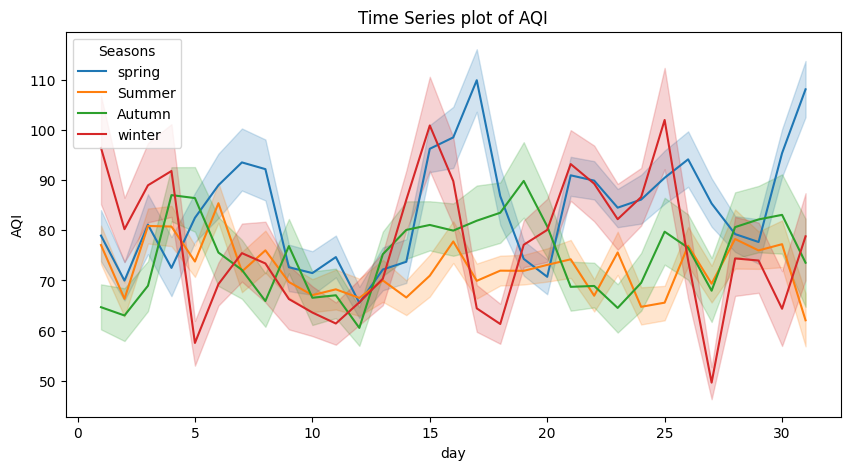

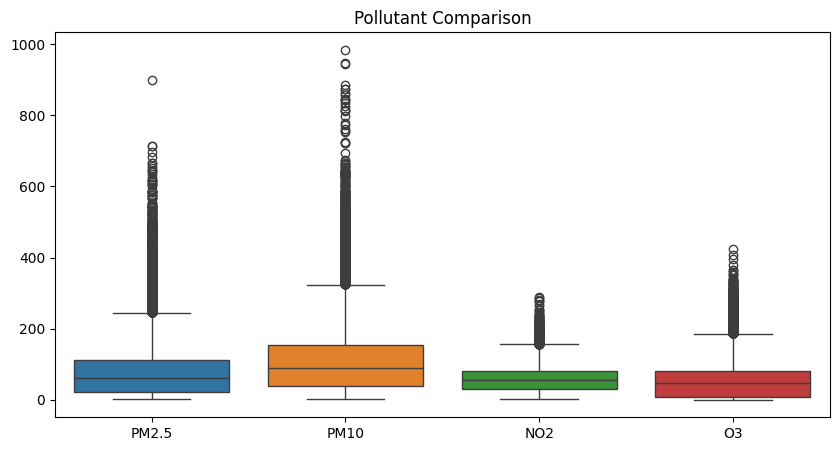

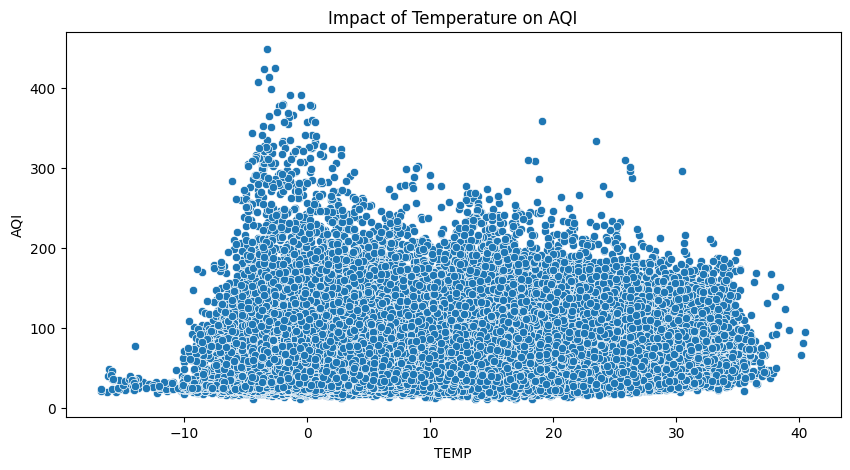

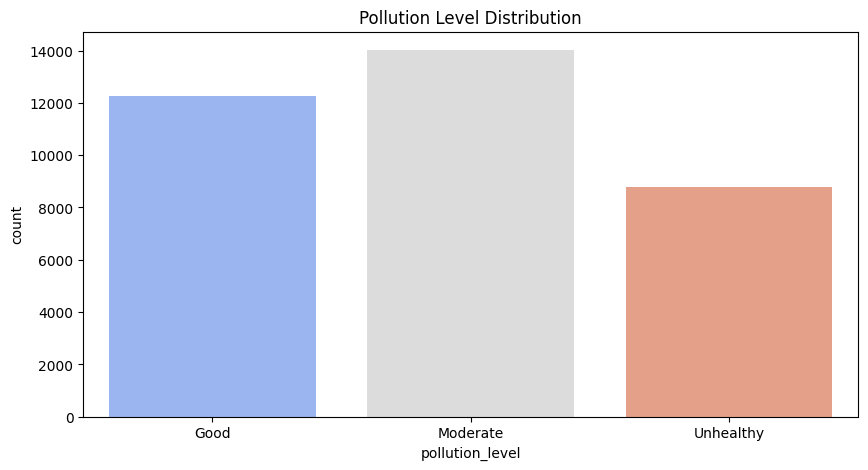

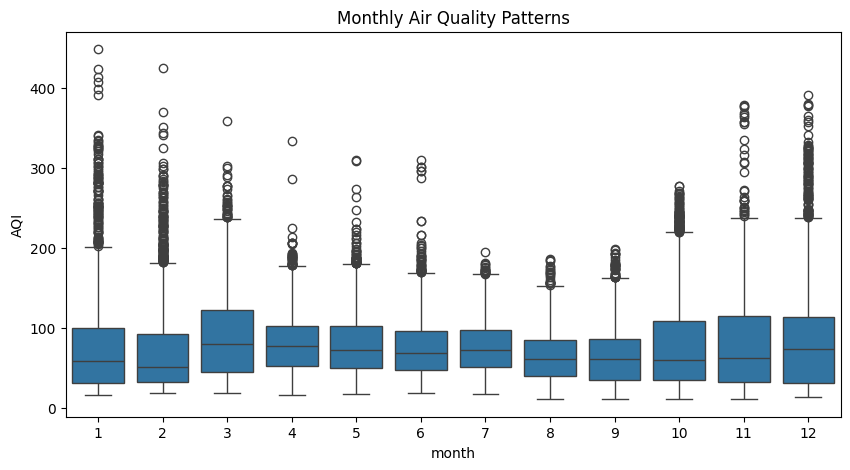

In [8]:
#Time series plot
plt.figure(figsize=(10,5)) #figure size 1000 x 500
sns.lineplot(data=df, x='day', y='AQI', hue='Seasons')
plt.title('Time Series plot of AQI')
plt.show()

# Box plot for pollutant comparison
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['PM2.5', 'PM10', 'NO2', 'O3']])
plt.title('Pollutant Comparison')
plt.show()

# Scatter plot for temperature vs AQI
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='TEMP', y='AQI')
plt.title('Impact of Temperature on AQI')
plt.show()

# Bar plot for pollution levels
plt.figure(figsize=(10, 5))
sns.countplot(x='pollution_level',hue = 'pollution_level', data=df, palette='coolwarm',legend = False)
plt.title('Pollution Level Distribution')
plt.show()

# Monthly AQI distribution
plt.figure(figsize=(10, 5))
sns.boxplot(x='month', y='AQI', data=df)
plt.title('Monthly Air Quality Patterns')
plt.show()
